In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('/Users/omartharwat/Desktop/Eplison/Final_project/cleaned_amazon_sales.csv')

The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.


In [4]:
df.head()

,Date,Status,Fulfilment,Sales Channel,ship-service-level,SKU,Category,Size,Courier Status,Qty,Amount,ship-city,ship-state,B2B,SKU_freq,year,month,day,Amount_missing
0,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389-KR-NP-S,Set,S,Unknown,0,647.62,MUMBAI,MAHARASHTRA,False,36,2022,4,30,0
1,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781-KR-XXXL,kurta,3XL,Shipped,1,406.00,BENGALURU,KARNATAKA,False,109,2022,4,30,0
2,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371-KR-XL,kurta,XL,Shipped,1,329.00,NAVI MUMBAI,MAHARASHTRA,True,14,2022,4,30,0
3,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341-DR-L,Western Dress,L,Unknown,0,753.33,PUDUCHERRY,PUDUCHERRY,False,292,2022,4,30,0
4,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671-TU-XXXL,Top,3XL,Shipped,1,574.00,CHENNAI,TAMIL NADU,False,17,2022,4,30,0


In [5]:
df.describe()

,Qty,Amount,SKU_freq,year,month,day,Amount_missing
count,126546.000000,126546.000000,126546.000000,126546.0,126546.000000,126546.000000,126546.000000
mean,0.907433,656.705339,88.701492,2022.0,4.910918,14.930136,0.018302
std,0.309754,259.149010,122.792178,0.0,0.818727,8.739558,0.134040
min,0.000000,0.000000,1.000000,2022.0,3.000000,1.000000,0.000000
25%,1.000000,469.000000,18.000000,2022.0,4.000000,7.000000,0.000000
50%,1.000000,603.000000,43.000000,2022.0,5.000000,15.000000,0.000000
75%,1.000000,771.000000,106.000000,2022.0,6.000000,22.000000,0.000000
max,15.000000,5584.000000,773.000000,2022.0,6.000000,31.000000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126546 entries, 0 to 126545
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Date                126546 non-null  object 
 1   Status              126546 non-null  object 
 2   Fulfilment          126546 non-null  object 
 3   Sales Channel       126546 non-null  object 
 4   ship-service-level  126546 non-null  object 
 5   SKU                 126546 non-null  object 
 6   Category            126546 non-null  object 
 7   Size                126546 non-null  object 
 8   Courier Status      126546 non-null  object 
 9   Qty                 126546 non-null  int64  
 10  Amount              126546 non-null  float64
 11  ship-city           126513 non-null  object 
 12  ship-state          126513 non-null  object 
 13  B2B                 126546 non-null  bool   
 14  SKU_freq            126546 non-null  int64  
 15  year                126546 non-nul

In [7]:
# 1) SKU frequency
df['SKU_freq'] = df['SKU'].map(df['SKU'].value_counts())

# 2) Extract SKU parts
df['sku_type'] = df['SKU'].str.split('-').str[1]
df['sku_size'] = df['SKU'].str.split('-').str[-1]

In [8]:
df.head()

,Date,Status,Fulfilment,Sales Channel,ship-service-level,SKU,Category,Size,Courier Status,Qty,...,ship-city,ship-state,B2B,SKU_freq,year,month,day,Amount_missing,sku_type,sku_size
0,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389-KR-NP-S,Set,S,Unknown,0,...,MUMBAI,MAHARASHTRA,False,36,2022,4,30,0,KR,S
1,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781-KR-XXXL,kurta,3XL,Shipped,1,...,BENGALURU,KARNATAKA,False,108,2022,4,30,0,KR,XXXL
2,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371-KR-XL,kurta,XL,Shipped,1,...,NAVI MUMBAI,MAHARASHTRA,True,14,2022,4,30,0,KR,XL
3,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341-DR-L,Western Dress,L,Unknown,0,...,PUDUCHERRY,PUDUCHERRY,False,270,2022,4,30,0,DR,L
4,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671-TU-XXXL,Top,3XL,Shipped,1,...,CHENNAI,TAMIL NADU,False,17,2022,4,30,0,TU,XXXL


In [9]:
# Drop raw SKU after extracting useful features
df.drop(columns=['SKU','Amount_missing'], inplace=True)

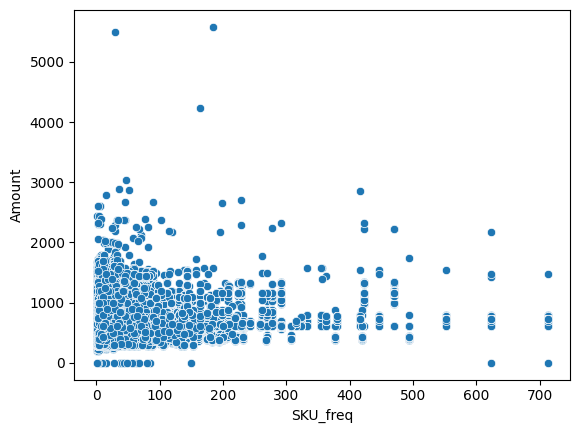

In [10]:


sns.scatterplot(
    x='SKU_freq',
    y='Amount',
    data=df
)

plt.show()

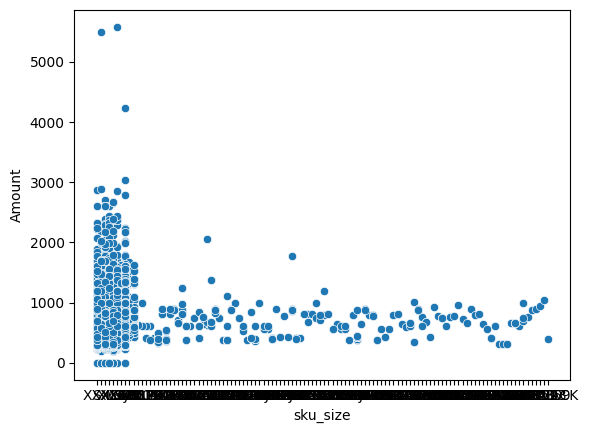

In [11]:

sns.scatterplot(
    x='sku_size',
    y='Amount',
    data=df
)

plt.show()

In [45]:
cat_cols = ['Category', 'Size', 'Fulfilment', 'ship-state', 'sku_type', 'sku_size']
num_cols = ['Qty', 'month', 'SKU_freq']


In [46]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            Pipeline([
                ('onehot', OneHotEncoder(handle_unknown='ignore',sparse_output=False))
            ]),
            cat_cols
        )
    ]
)

In [47]:
X = df.drop('Amount', axis=1)
y = df['Amount']


In [48]:
y = np.log1p(df['Amount'])

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (101236, 18)
X_test shape: (25310, 18)
y_train shape: (101236,)
y_test shape: (25310,)


In [50]:
from catboost import CatBoostRegressor
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', CatBoostRegressor(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    loss_function='RMSE',
    verbose=0,
    random_state=42,
    allow_writing_files=False
)
)
])


In [51]:
pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Category', 'Size',
                                                   'Fulfilment', 'ship-state',
                                                   'sku_type', 'sku_size'])])),
                ('model',
                 CatBoostRegressor(allow_writing_files=False, depth=8, iterations=500, learning_rate=0.05, loss_function='RMSE', random_state=42, verbose=0))])

In [52]:
pred = pipeline.predict(X_test)

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pred_log = pipeline.predict(X_test)

y_test_actual = np.expm1(y_test)
pred_actual = np.expm1(pred_log)

mae = mean_absolute_error(y_test_actual, pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, pred_actual))
r2 = r2_score(y_test_actual, pred_actual)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 120.86912794261205
RMSE: 171.32835350050343
R2: 0.5562870697236209


In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pred_log = pipeline.predict(X_test)

y_test_actual = np.expm1(y_test)
pred_actual = np.expm1(pred_log)

mae = mean_absolute_error(y_test_actual, pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, pred_actual))
r2 = r2_score(y_test_actual, pred_actual)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 120.86912794261205
RMSE: 171.32835350050343
R2: 0.5562870697236209


In [56]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, pred)
print(r2)


0.5585785628861506


In [57]:
from sklearn.dummy import DummyRegressor

dummy = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DummyRegressor(strategy='mean'))
])

dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

print("Dummy R2:", r2_score(y_test, dummy_pred))
print("Model R2:", r2_score(y_test, pred))


Dummy R2: -1.4091406772553938e-06
Model R2: 0.5585785628861506


In [64]:
from catboost import CatBoostRegressor
from xgboost import XGBRFRegressor
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRFRegressor(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
)
)
])


In [65]:
pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Category', 'Size',
                                                   'Fulfilment', 'ship-state',
                                                   'sku_type', 'sku_size'])])),
                ('model',
                 XGBRFRegressor(base_score=None, booster=None, callbacks=None,
                                colsample_bylevel=None, colsample_bytree=0.8,
                                device=...
                                gamma=None, grow_policy=None,
                                importance_type=None,
                                interaction_constraints=None,
                                learning_rate=0.05, max_bin=None,
                                max_cat_threshold=None, max_cat_to_onehot=None,
                                max_delta_step=None, max_depth=8,
                                max_leaves=None, min_child_weight=None,
                                missing=nan, monotone_constraints=None,
                                multi_strategy=None, n_estimators=500,
                                n_jobs=None, num_parallel_tree=None,
                                objective='reg:squarederror', ...))])

In [66]:
pred = pipeline.predict(X_test)

In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pred_log = pipeline.predict(X_test)

y_test_actual = np.expm1(y_test)
pred_actual = np.expm1(pred_log)

mae = mean_absolute_error(y_test_actual, pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, pred_actual))
r2 = r2_score(y_test_actual, pred_actual)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 187.3058211424431
RMSE: 255.31702611436214
R2: 0.014621331038067287
